In [ ]:
!pip install ultralytics

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 41.2/41.2 kB 1.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 38.1 MB/s eta 0:00:00


In [ ]:
!unzip "/content/Final truck Cabin Detection.v1i.yolov8.zip"

Archive:  /content/Final truck Cabin Detection.v1i.yolov8.zip
 extracting: train/images/U2UL1_2026-06-01_23-42-41_jpg.rf.9748ec3c93d8ef85d260ee245f905e2d.jpg  
 extracting: train/images/U2UL1_2026-06-02_12-28-57_jpg.rf.69190842d3ca59fe242172c77e91fd59.jpg  
 extracting: train/images/U2UL1_2026-06-02_10-08-07_jpg.rf.92755d3004a43e2936b38dac5b48aed9.jpg  
 extracting: train/images/U2UL1_2026-06-02_09-28-06_jpg.rf.9d7498e65c16fe5de1af785a87bea032.jpg  
 extracting: train/images/entry_2026-06-02_14-27-08_lid21_noplate_jpg.rf.24ca431b8e36cd44b4ba7a7ba9d3ee0b.jpg  
 extracting: train/images/U2UL1_2026-06-02_00-02-42_jpg.rf.6d35e2175e7f7ba9fa25d8993e87e949.jpg  
 extracting: train/images/U2UL1_2026-06-01_23-47-42_jpg.rf.090e739fe6291afdb15edf73b846514f.jpg  
 extracting: train/images/U2UL1_2026-06-02_03-22-50_jpg.rf.9b32d505aaeda70e67079ebfa3a917b9.jpg  
 extracting: train/images/U2UL1_2026-06-02_13-11-02_jpg.rf.ccb263778aea9a5fb5a692cb7bb74662.jpg  
 extracting: train/images/U2UL1_2026-06-02

In [ ]:
!ls

 data.yaml				       README.roboflow.txt
'Final truck Cabin Detection.v1i.yolov8.zip'   sample_data
 README.dataset.txt			       train


In [ ]:
import os
import shutil
from sklearn.model_selection import train_test_split

base = "/content/train"

images = os.listdir(f"{base}/images")

train_imgs, temp_imgs = train_test_split(
    images,
    test_size=0.30,
    random_state=42
)

valid_imgs, test_imgs = train_test_split(
    temp_imgs,
    test_size=0.50,
    random_state=42
)

for split in ["train_new", "valid", "test"]:
    os.makedirs(f"/content/{split}/images", exist_ok=True)
    os.makedirs(f"/content/{split}/labels", exist_ok=True)

def copy_files(file_list, dest):
    for img in file_list:

        shutil.copy(
            f"{base}/images/{img}",
            f"/content/{dest}/images/{img}"
        )

        label = img.rsplit(".",1)[0] + ".txt"

        shutil.copy(
            f"{base}/labels/{label}",
            f"/content/{dest}/labels/{label}"
        )

copy_files(train_imgs, "train_new")
copy_files(valid_imgs, "valid")
copy_files(test_imgs, "test")

print("Dataset Split Complete")

Dataset Split Complete


In [ ]:
%%writefile /content/data.yaml

train: /content/train_new/images
val: /content/valid/images
test: /content/test/images

nc: 1
names: ['cabin']

Overwriting /content/data.yaml


In [ ]:
from ultralytics import YOLO

model = YOLO("yolov8n.pt")

results = model.train(
    data="/content/data.yaml",
    epochs=50,
    batch=4,
    imgsz=512
)

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
Ultralytics 8.4.60 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=4, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/data.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=50, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=512, in

In [ ]:
!ls runs/detect/train/weights

best.pt  last.pt


In [ ]:
metrics=model.val()

Ultralytics 8.4.60 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
Model summary (fused): 73 layers, 3,005,843 parameters, 0 gradients, 8.1 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 1330.7±572.8 MB/s, size: 47.1 KB)
val: Scanning /content/valid/labels.cache... 102 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 102/102 32.9Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 7/7 3.1it/s 2.2s
                   all        102        113      0.982          1      0.988       0.87
Speed: 3.3ms preprocess, 4.8ms inference, 0.0ms loss, 2.2ms postprocess per image
Results saved to /content/runs/detect/val


In [ ]:
!ls runs/detect/train

args.yaml			 results.csv	      val_batch0_labels.jpg
BoxF1_curve.png			 results.png	      val_batch0_pred.jpg
BoxP_curve.png			 train_batch0.jpg     val_batch1_labels.jpg
BoxPR_curve.png			 train_batch1.jpg     val_batch1_pred.jpg
BoxR_curve.png			 train_batch2.jpg     val_batch2_labels.jpg
confusion_matrix_normalized.png  train_batch4760.jpg  val_batch2_pred.jpg
confusion_matrix.png		 train_batch4761.jpg  weights
labels.jpg			 train_batch4762.jpg


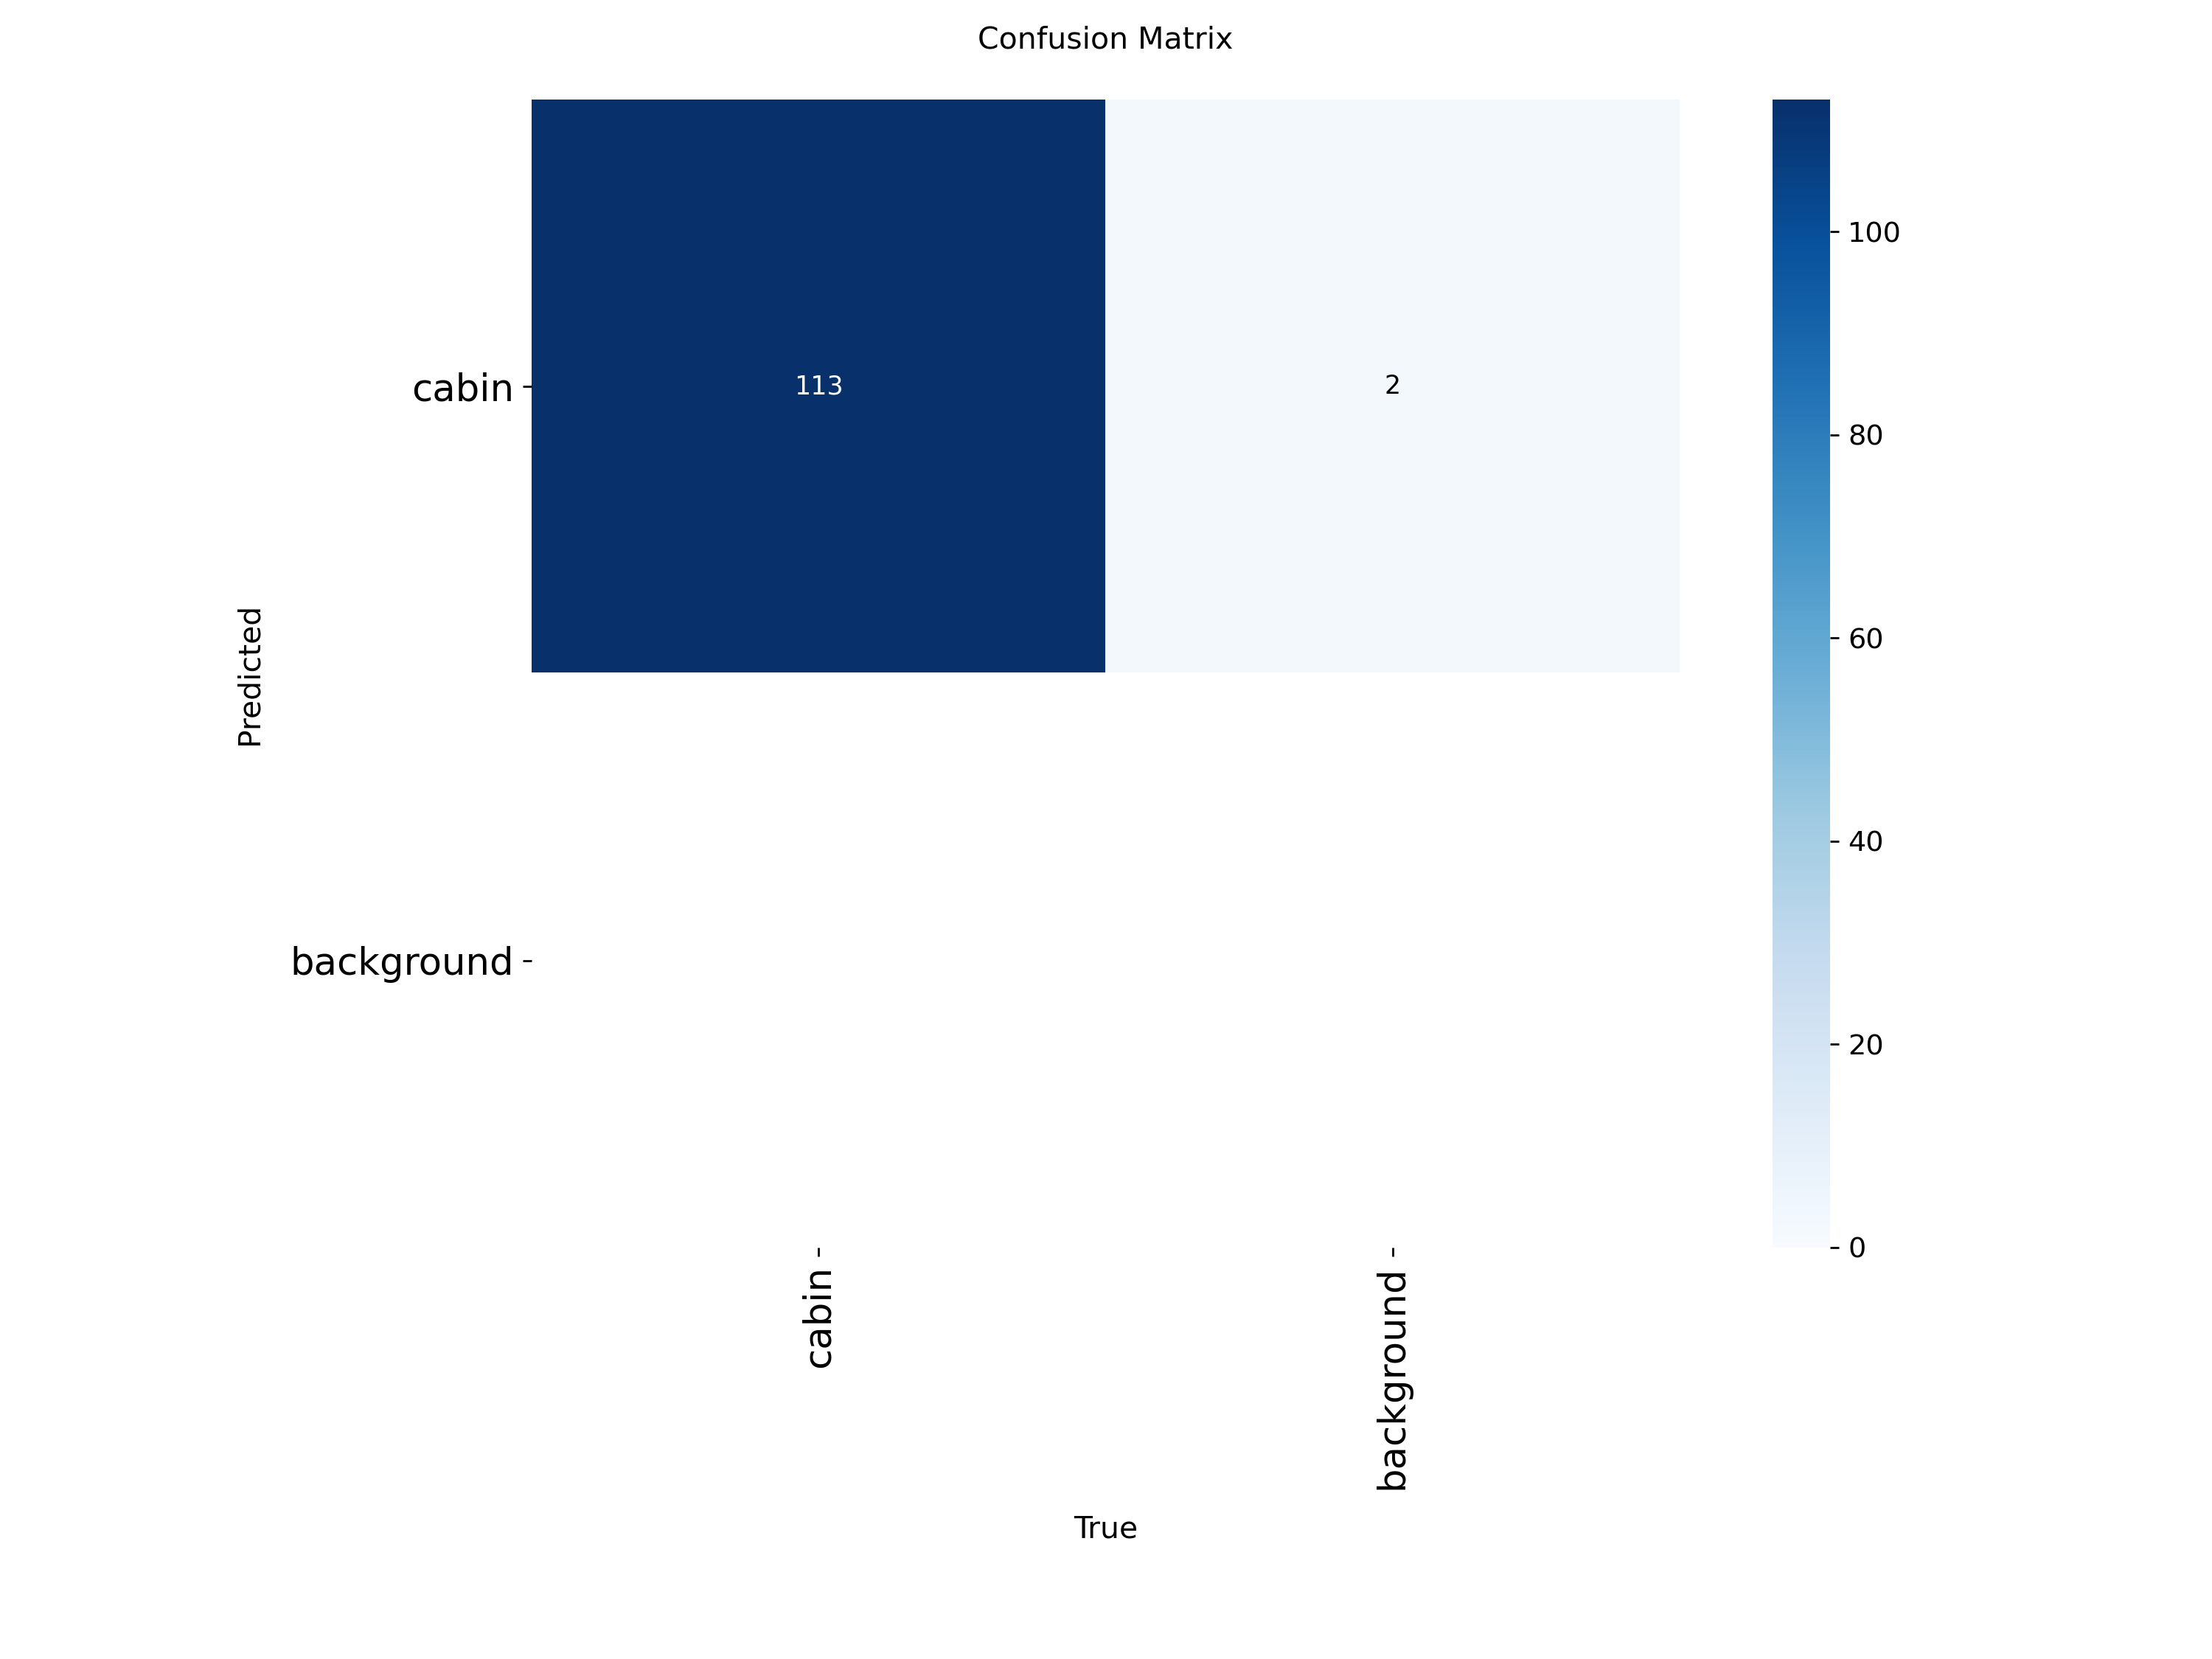

In [ ]:
from IPython.display import Image

Image("runs/detect/train/confusion_matrix.png")

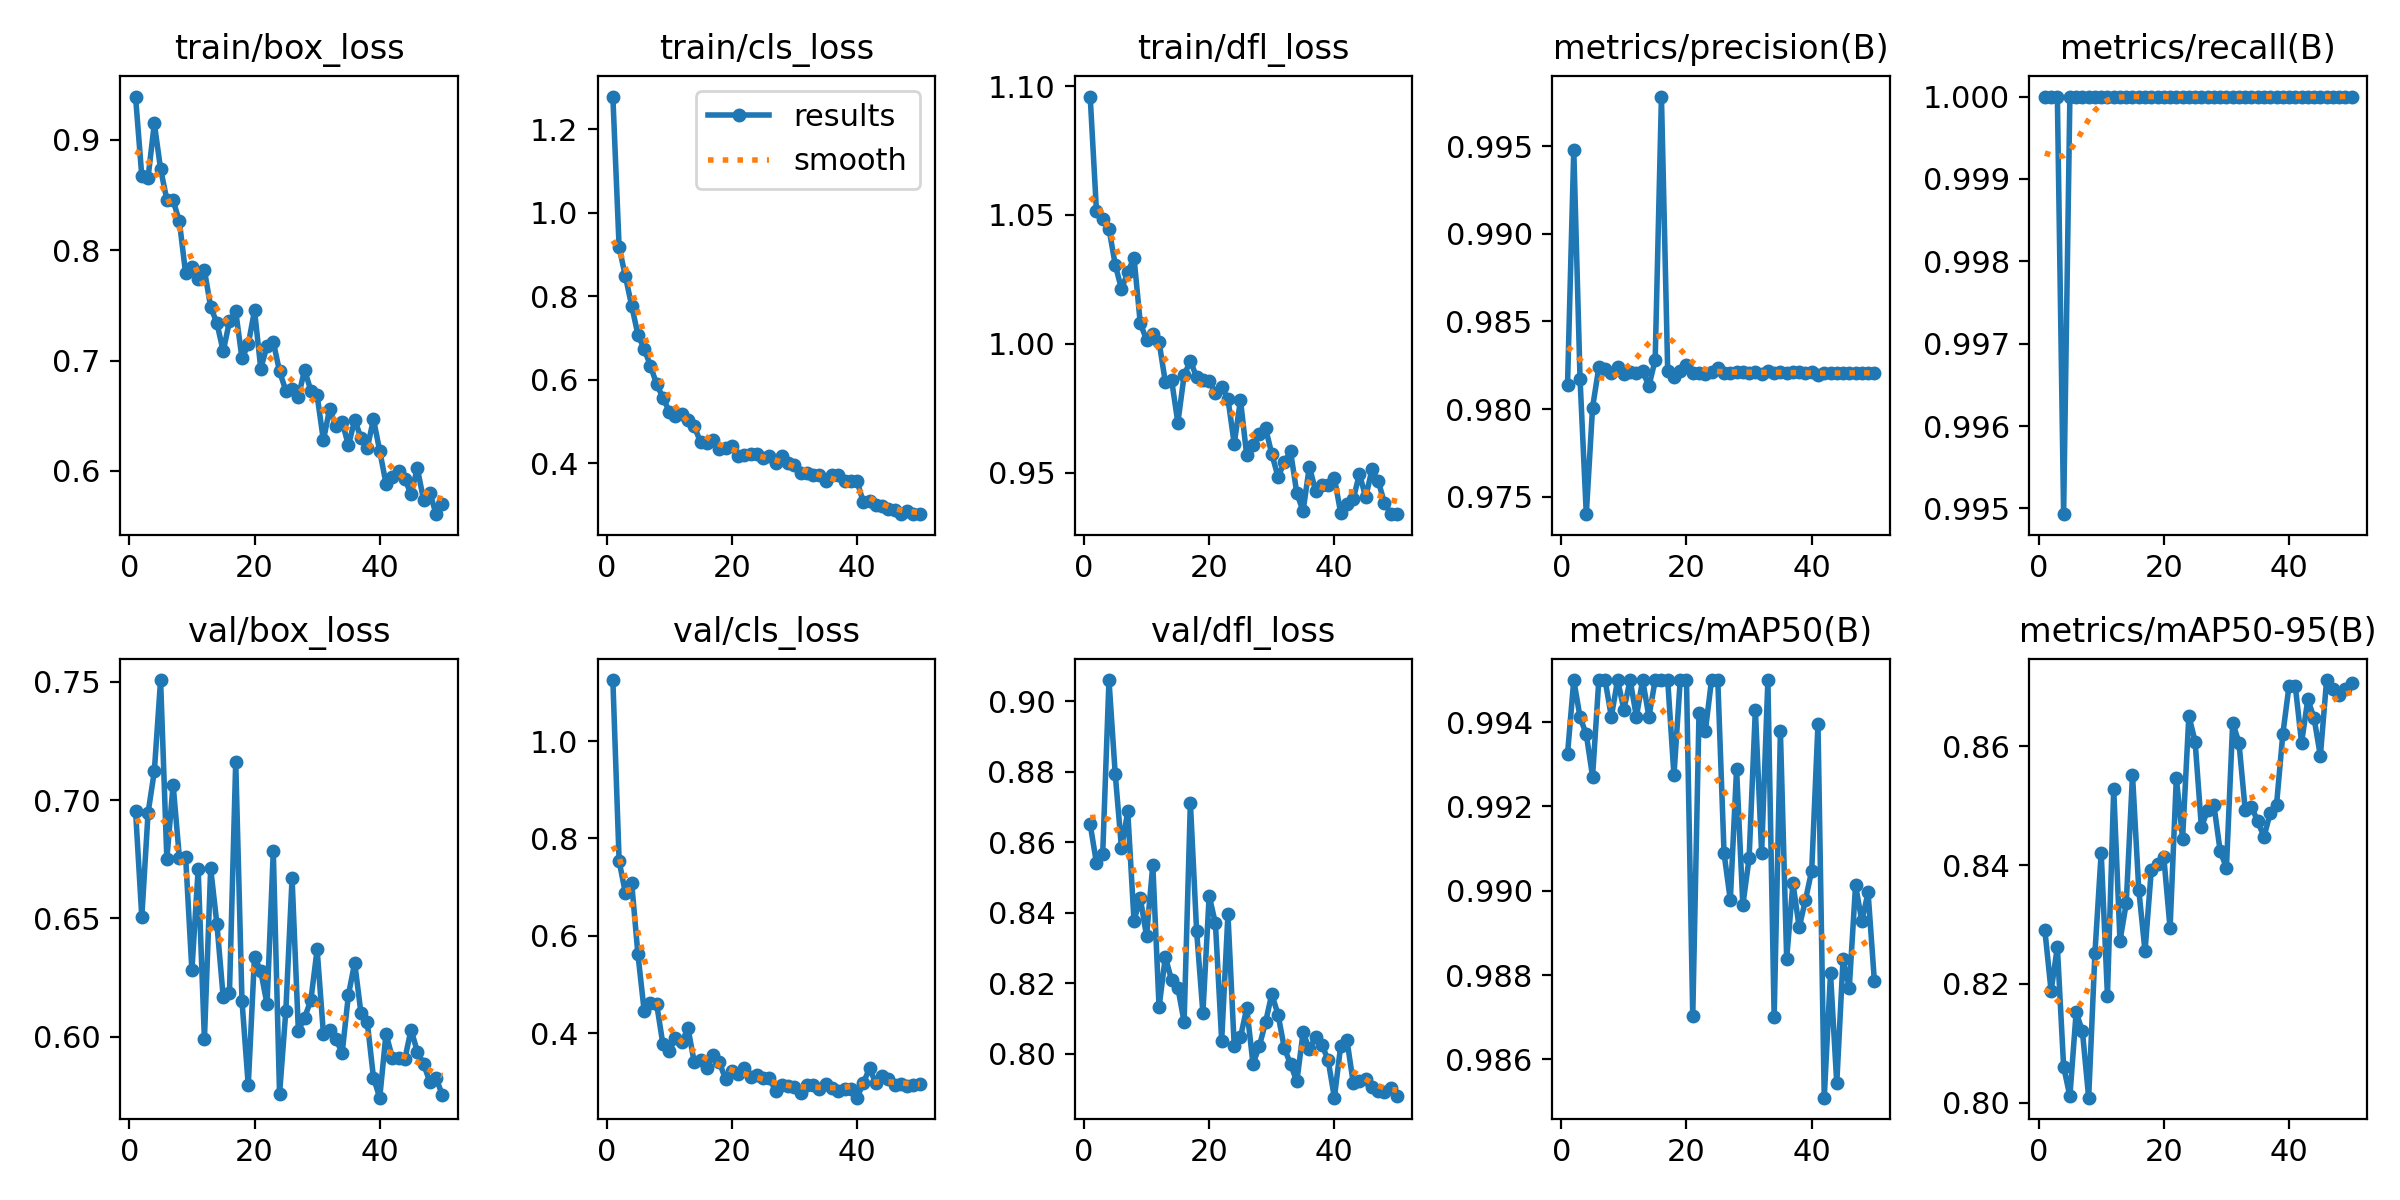

In [ ]:
Image("runs/detect/train/results.png")

In [ ]:
!ls runs/detect/train/weights

best.pt  last.pt


In [ ]:
from ultralytics import YOLO

model = YOLO("runs/detect/train/weights/best.pt")

results = model.predict(
    source="/content/test/images",
    save=True
)


image 1/102 /content/test/images/U2UL1_2026-06-01_13-19-27_jpg.rf.19616ae530fcf1fb6a4fb3ada11ba6b8.jpg: 512x512 1 cabin, 8.7ms
image 2/102 /content/test/images/U2UL1_2026-06-01_13-24-27_jpg.rf.3fd7dbe8be5ad3cc524e1df9a91fab9f.jpg: 512x512 1 cabin, 6.4ms
image 3/102 /content/test/images/U2UL1_2026-06-01_13-24-27_jpg.rf.49babf700b635b2335c5e6100039c0dd.jpg: 512x512 1 cabin, 6.3ms
image 4/102 /content/test/images/U2UL1_2026-06-01_13-24-27_jpg.rf.d3490cb1cd53a7a9030ee074adea3b57.jpg: 512x512 1 cabin, 5.9ms
image 5/102 /content/test/images/U2UL1_2026-06-01_13-29-27_jpg.rf.5f878fd742c458c0686d44d0f98cbdd2.jpg: 512x512 1 cabin, 6.0ms
image 6/102 /content/test/images/U2UL1_2026-06-01_13-29-27_jpg.rf.7d1d14a7aeb86a315671e7d8b4ea6118.jpg: 512x512 1 cabin, 6.0ms
image 7/102 /content/test/images/U2UL1_2026-06-01_13-49-28_jpg.rf.0189caf1e4865d28c6c7515814a8a7cd.jpg: 512x512 1 cabin, 6.0ms
image 8/102 /content/test/images/U2UL1_2026-06-01_13-54-28_jpg.rf.70e02b09b590ea90b44a0540ce1c38a4.jpg: 512x51

In [ ]:
!ls runs/detect/predict

entry_2026-06-02_13-11-48_lid1_noplate_jpg.rf.90aec3453ba6b0ed4ab51d80eb950c4b.jpg
entry_2026-06-02_13-58-22_lid15_noplate_jpg.rf.d888b6ff22751097cf509b97e0aecbd0.jpg
U2UL1_2026-06-01_13-19-27_jpg.rf.19616ae530fcf1fb6a4fb3ada11ba6b8.jpg
U2UL1_2026-06-01_13-24-27_jpg.rf.3fd7dbe8be5ad3cc524e1df9a91fab9f.jpg
U2UL1_2026-06-01_13-24-27_jpg.rf.49babf700b635b2335c5e6100039c0dd.jpg
U2UL1_2026-06-01_13-24-27_jpg.rf.d3490cb1cd53a7a9030ee074adea3b57.jpg
U2UL1_2026-06-01_13-29-27_jpg.rf.5f878fd742c458c0686d44d0f98cbdd2.jpg
U2UL1_2026-06-01_13-29-27_jpg.rf.7d1d14a7aeb86a315671e7d8b4ea6118.jpg
U2UL1_2026-06-01_13-49-28_jpg.rf.0189caf1e4865d28c6c7515814a8a7cd.jpg
U2UL1_2026-06-01_13-54-28_jpg.rf.70e02b09b590ea90b44a0540ce1c38a4.jpg
U2UL1_2026-06-01_13-54-28_jpg.rf.f609b753f6145f4b52697e55b8e38099.jpg
U2UL1_2026-06-01_14-04-28_jpg.rf.48f6bf9ae4f3e6c33afe67c980823bc4.jpg
U2UL1_2026-06-01_14-19-29_jpg.rf.98fb0606f07f65a1398d3e6b59cde55f.jpg
U2UL1_2026-06-01_14-24-29_jpg.rf.b5cea8a3a1643e218bbc8fcd80ac13

In [ ]:
metrics = model.val()
print(metrics)

Ultralytics 8.4.60 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 1953.7±409.4 MB/s, size: 49.5 KB)
val: Scanning /content/valid/labels.cache... 102 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 102/102 38.9Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 7/7 3.5it/s 2.0s
                   all        102        113      0.982          1      0.988       0.87
Speed: 3.8ms preprocess, 3.5ms inference, 0.0ms loss, 2.4ms postprocess per image
Results saved to /content/runs/detect/val-3
ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array([0])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x7b904a69eae0>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)']
curves_results: [[array([          0,    0.00

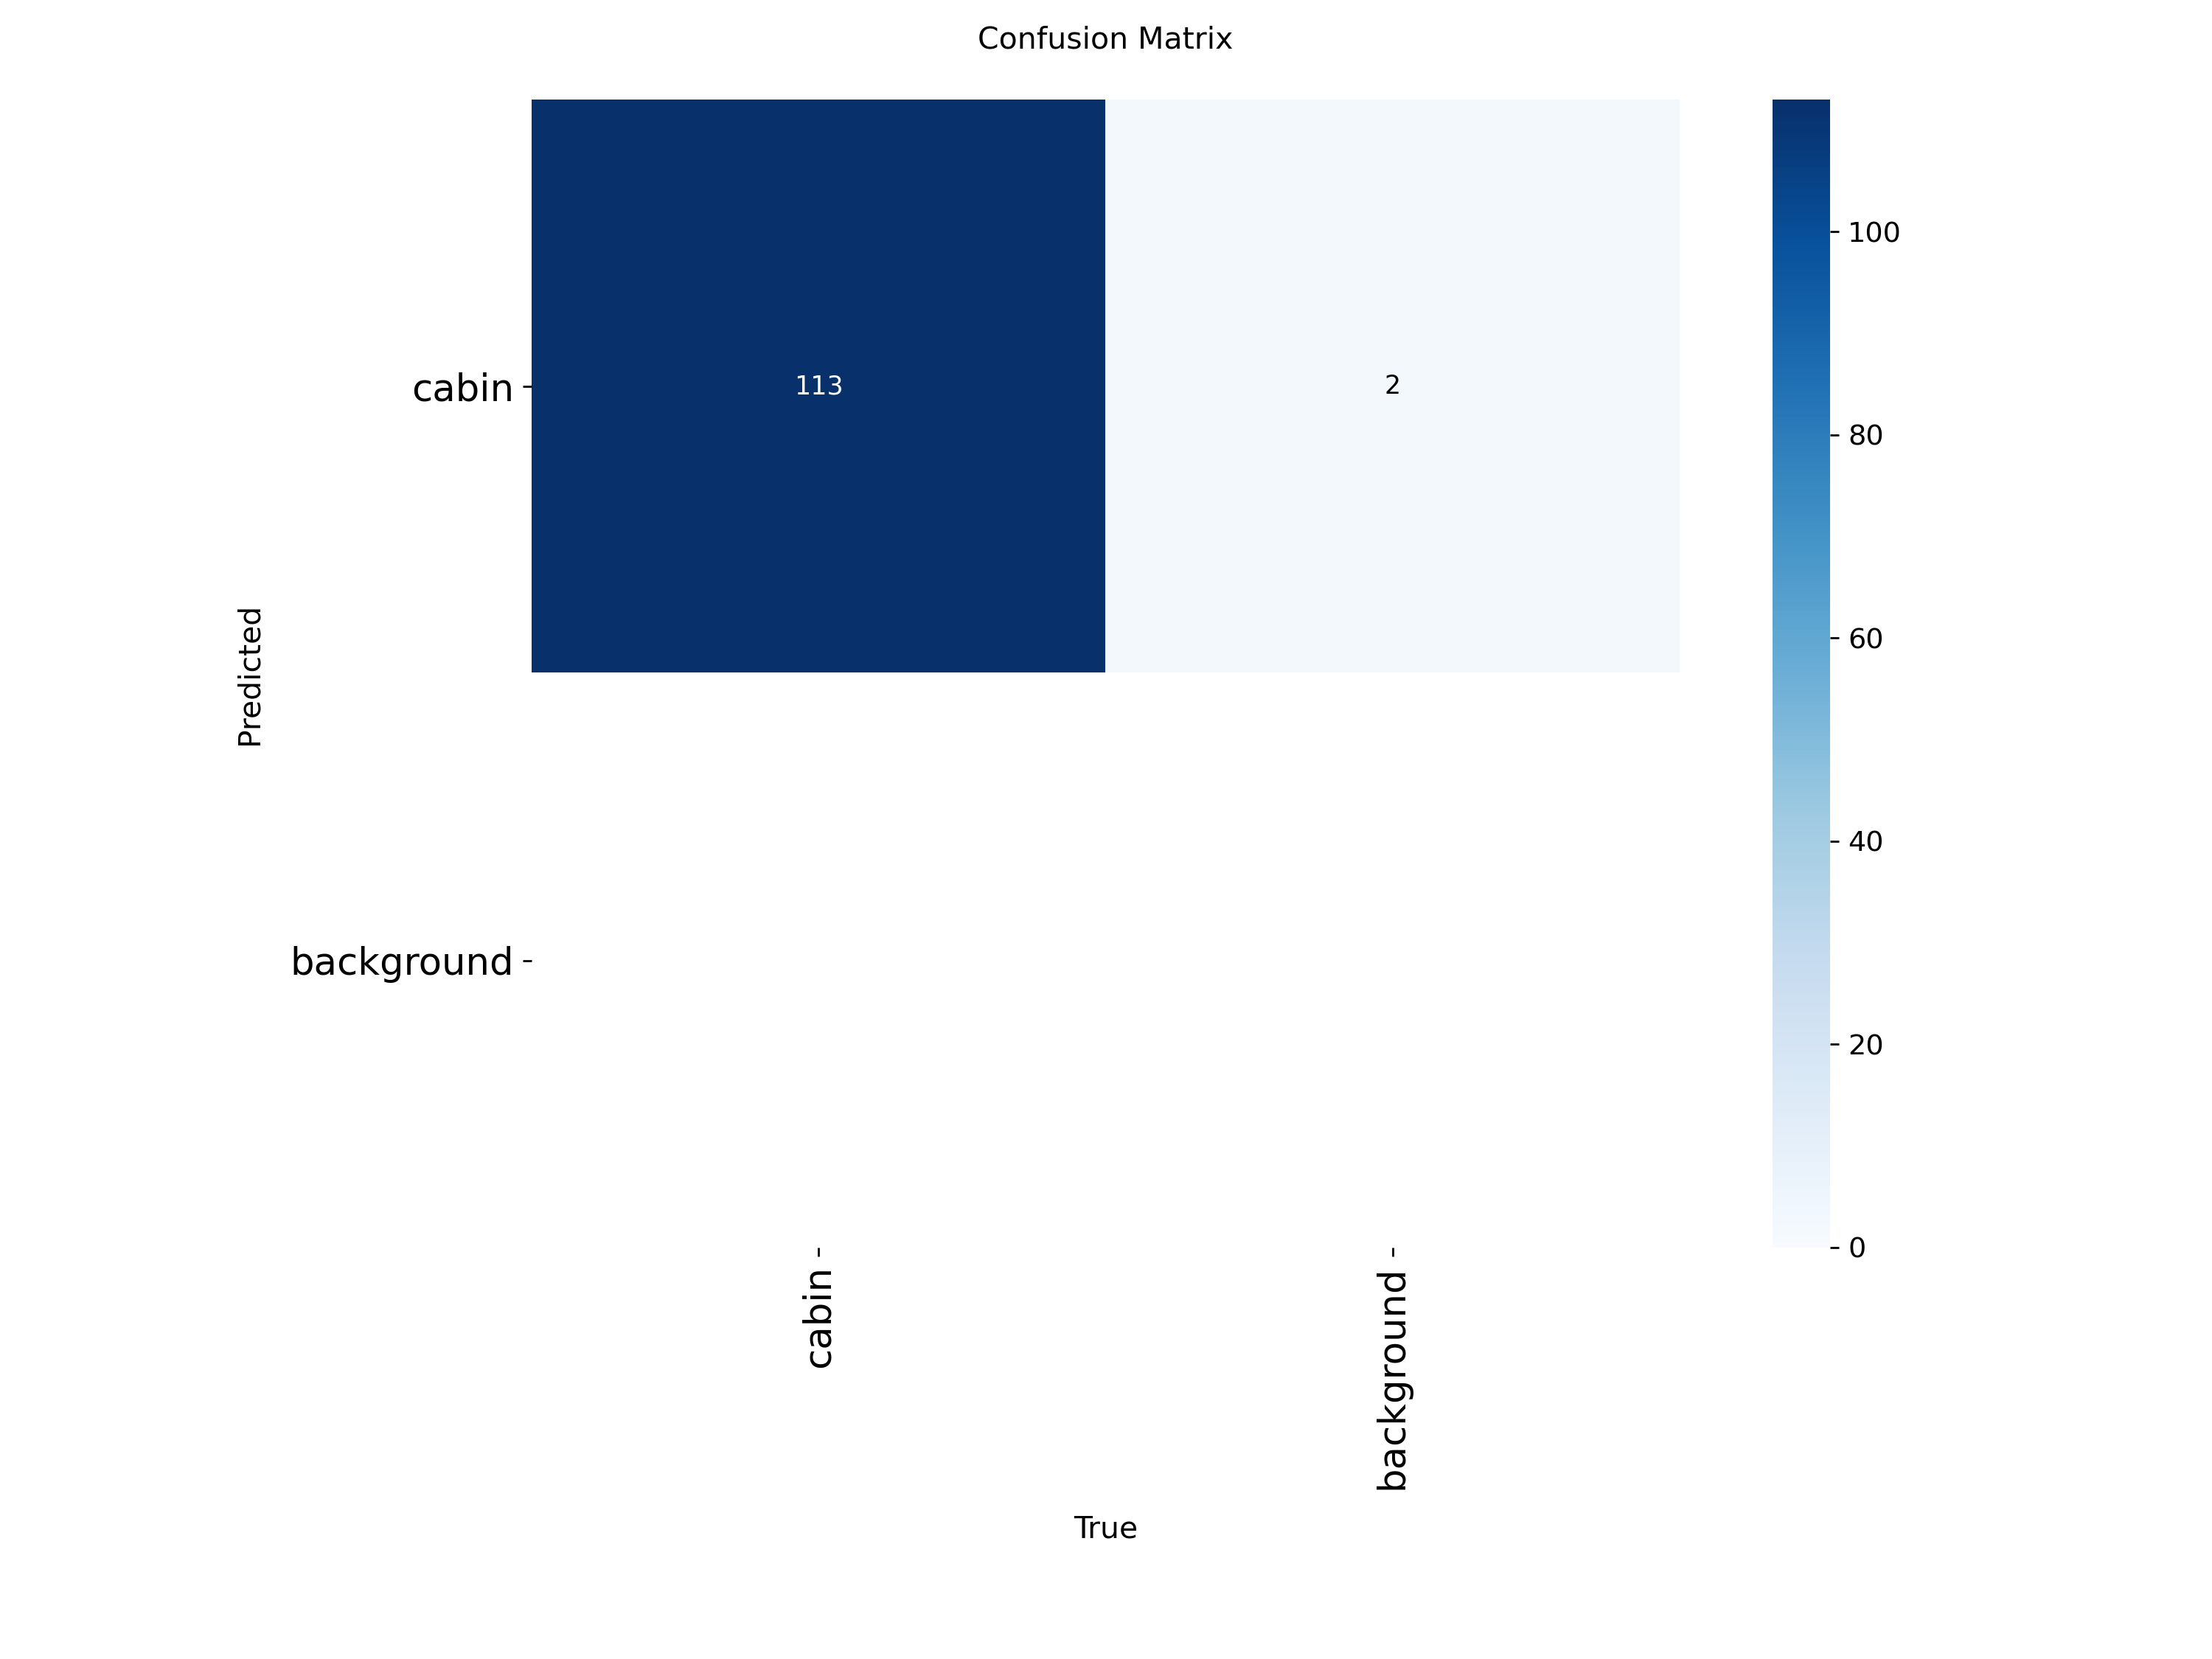

In [ ]:
from IPython.display import Image
Image("/content/runs/detect/train/confusion_matrix.png")

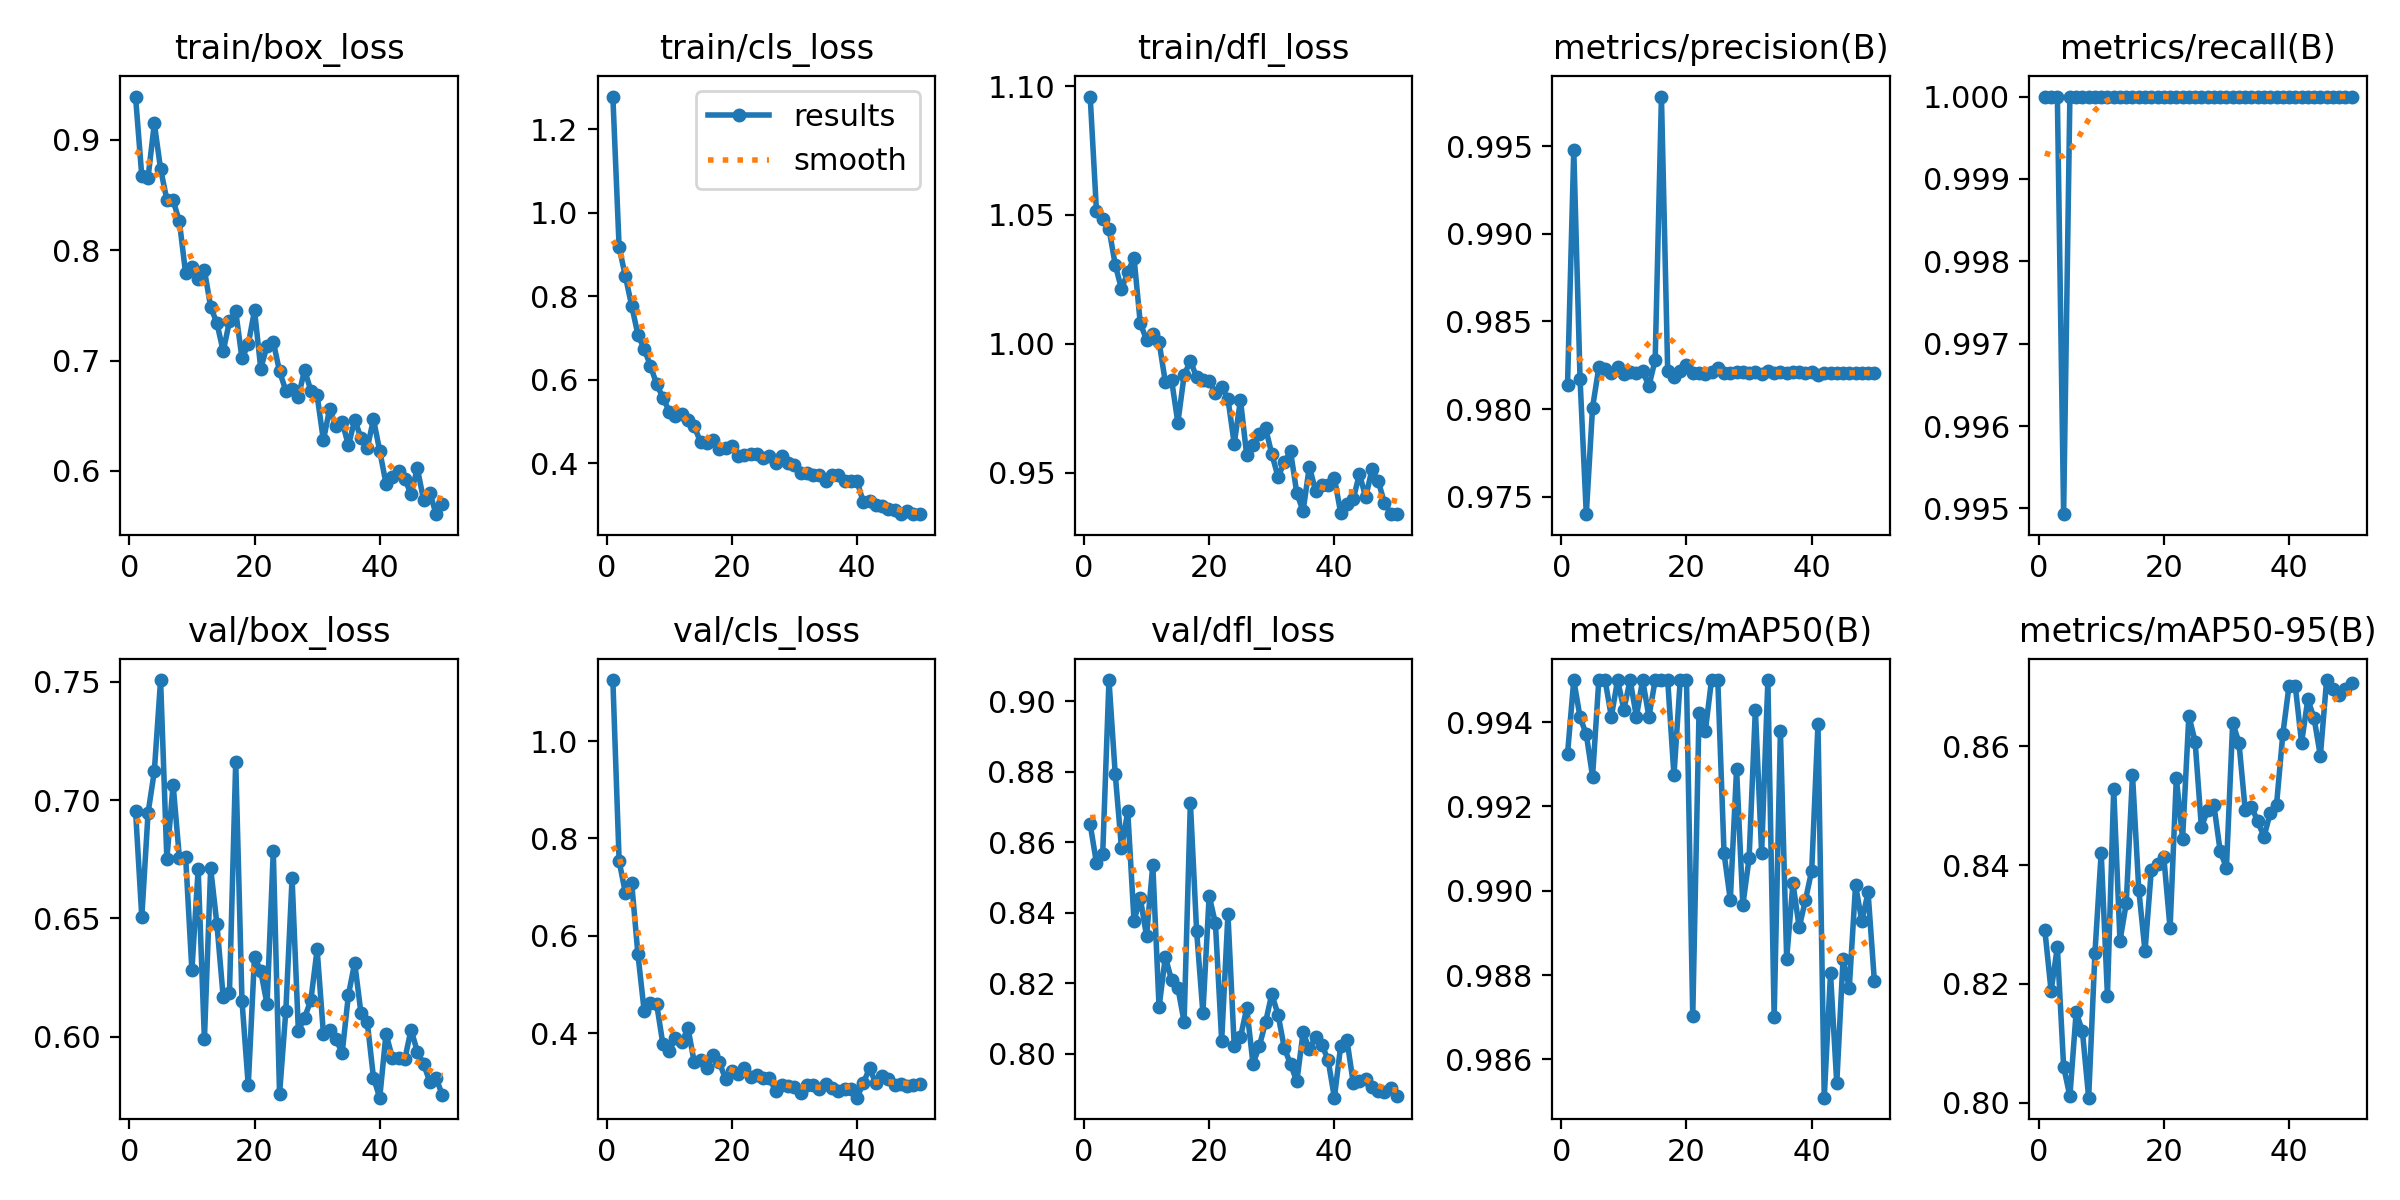

In [ ]:
from IPython.display import Image
Image("/content/runs/detect/train/results.png")

In [ ]:
!find /content/runs -name "best.pt"

/content/runs/detect/train/weights/best.pt


In [ ]:
from google.colab import files

files.download('/content/runs/detect/train/weights/best.pt')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>